## 13. Εκτίμηση Συμφωνίας

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Μέσω των πολλαπλών επισημειώσεων (ανα στιγμιότυπο) μπορούμε να εκτιμήσουμε τον βαθμό συμφωνίας. Η συμφωνία των κριτών (Inter-Annotator Agreement, IAA) αποτελεί ένα βασικό μέτρο αξιοπιστίας της επισημείωσης. Μία υψηλή τιμή δείχνει σαφείς οδηγίες και καλά ορισμένο σχήμα επισημείωσης. Από την άλλη πλευρά, μία χαμηλή συμφωνία δείχνει προβληματικές οδηγίες, την ύπαρξη υποκειμενισμού ή κάποια πολυσημία.


In [ ]:
import pandas as pd
import numpy as np
np.random.seed(2026)
annots = pd.DataFrame({"A1": np.random.randint(0,2,100),
                       "A2": np.random.randint(0,2,100)})
annots.sample(3, random_state=2026)

,A1,A2
98,0,1
10,1,1
4,1,0


In [ ]:
annots["agreement"] = (annots.A1==annots.A2)
annots.sample(3, random_state=2026)

,A1,A2,agreement
98,0,1,False
10,1,1,True
4,1,0,False


In [ ]:
import numpy as np
annots['xor'] = np.logical_xor(annots.A1, annots.A2)
annots

,A1,A2,agreement,xor
0,1,1,True,False
1,0,1,False,True
2,0,0,True,False
3,0,0,True,False
4,1,0,False,True
...,...,...,...,...
95,1,0,False,True
96,0,1,False,True
97,0,1,False,True
98,0,1,False,True


In [ ]:
print(f"Percentage Agreement: {annots.agreement.mean()*100:.2f}%")

Percentage Agreement: 50.00%


In [ ]:
xor = np.logical_xor(annots.A1, annots.A2)
annots.apply(lambda r: not np.logical_xor(r.A1, r.A2), axis=1)

,0
0,True
1,False
2,True
3,True
4,False
...,...
95,False
96,False
97,False
98,False


In [ ]:
# all possible outcomes
ncounts = annots.loc[:, ["A1","A2"]].value_counts(normalize=True)
ncounts

,,proportion
A1,A2,
1,1,0.27
0,1,0.25
1,0,0.25
0,0,0.23


In [ ]:
# A1 to say 0
ncounts.loc[:, 1] # all cases where A2 is 0

,proportion
A1,
1,0.27
0,0.25


How often each said each category

In [ ]:
print(f'P(A2 said 0) = {ncounts.loc[:, 0].sum():.2f}') # p(A2 will say 0)
print(f'P(A2 said 1) = {ncounts.loc[:, 1].sum():.2f}') # p(A2 will say 1)

P(A2 said 0) = 0.48
P(A2 said 1) = 0.52


In [ ]:
print(f'P(A1 said 0) = {ncounts.loc[0, :].sum():.2f}')
print(f'P(A1 said 1) = {ncounts.loc[1, :].sum():.2f}')

P(A1 said 0) = 0.48
P(A1 said 1) = 0.52


Putting it all together

In [ ]:
pe1 = ncounts.loc[1, :].sum() * ncounts.loc[:, 1].sum() # both said 1
pe0 = ncounts.loc[0, :].sum() * ncounts.loc[:, 0].sum() # both said 0
pe = pe0+pe1 # the probability that the raters agreed by chance
print (f'{pe:.2f} (= {pe0:.2f} + {pe1:.2f})')

0.50 (= 0.23 + 0.27)


In [ ]:
pa = ncounts[1,1] + ncounts[0,0] # computed analytically
k = (pa-pe) / (1-pe)
print(f"{k:G}")

-0.00160256


In [ ]:
from sklearn.metrics import cohen_kappa_score as kappa
k = kappa(annots.A1, annots.A2)
print(f"{k:g}")

-0.00160256


#### Many annotators

In [ ]:
#!pip install krippendorff
import krippendorff
import numpy as np

# Every row is an annotator, columns are points
data = np.array([
    [0,1,2,2,1,0,1,2,0,1],
    [0,2,2,2,1,0,1,1,0,1],
    [0,1,2,1,1,0,1,2,0,1]
])

alpha = krippendorff.alpha(data)

print(f"Krippendorff's alpha: {alpha:.3f}")

Krippendorff's alpha: 0.829


### 13.4 Εφαρμογή: Εκτίμηση συναισθήματος

In [ ]:
import openpyxl
openpyxl.reader.excel.warnings.simplefilter(action='ignore')

In [ ]:
import pandas as pd

a1 = pd.read_excel('ann3.xlsx')
a2 = pd.read_excel('ann4.xlsx')
a2.sample()

,song_id,title,lyrics,group,categories,suggestion,certainty
35,3b8a034a-2bf8-47fb-ae9f-dad2844757b3,LIAN1545,"Ταμπακέρα μὲ ταμπάκο,\nτσίμπλα μου, κατέβα κάτω.",lianotragouda,ΚΟΙΝΩΝΙΚΑ / ΣΑΤΙΡΙΚΑ,NaN,3


In [ ]:
data = pd.DataFrame()
data['title'] = a1.title
data['lyrics'] = a1.lyrics
data['judge1_emotions'] = a1.categories
data['judge2_emotions'] = a2.categories
data['judge1_certainty'] = a1.certainty
data['judge2_certainty'] = a2.certainty
data.sample()

,title,lyrics,judge1_emotions,judge2_emotions,judge1_certainty,judge2_certainty
17,LIAN0965,"Μισεύει τὸ πουλάκι μου, ποτὲ δὲν θὰ γελάσω,\nκ...",ΞΕΝΙΤΙΑ / ΜΕΤΑΝΑΣΤΕΥΣΗ,ΞΕΝΙΤΙΑ / ΜΕΤΑΝΑΣΤΕΥΣΗ,4.0,5


In [ ]:
print(data.judge1_emotions.unique())

['ΑΓΑΠΗ / ΕΡΩΤΑΣ / ΦΛΕΡΤ' 'ΕΡΩΤΙΚΗ ΔΙΑΨΕΥΣΗ' 'ΞΕΝΙΤΙΑ / ΜΕΤΑΝΑΣΤΕΥΣΗ'
 'ΨΥΧΙΚΟΣ ΠΟΝΟΣ / ΣΥΝΑΙΣΘΗΜΑΤΙΚΗ ΟΔΥΝΗ' 'ΛΟΙΠΑ / ΑΔΙΕΥΚΡΙΝΙΣΤΑ'
 'ΑΡΠΑΓΗ / ΚΛΕΨΙΜΟ ΝΥΦΗΣ' 'ΠΡΟΔΟΣΙΑ / ΖΗΛΙΑ' 'ΠΑΡΑΛΟΓΕΣ / ΑΦΗΓΗΜΑΤΙΚΑ'
 'ΓΑΜΟΣ / ΝΥΦΙΑΤΙΚΑ' 'ΗΡΩΙΚΑ / ΚΛΕΦΤΙΚΑ' 'ΘΑΝΑΤΟΣ / ΜΟΙΡΟΛΟΓΙΑ'
 'ΠΟΛΕΜΟΣ / ΜΑΧΕΣ' 'ΚΟΙΝΩΝΙΚΑ / ΣΑΤΙΡΙΚΑ' 'ΙΣΤΟΡΙΚΑ ΓΕΓΟΝΟΤΑ'
 'ΟΙΚΟΓΕΝΕΙΑ / ΣΥΓΓΕΝΕΙΑ']


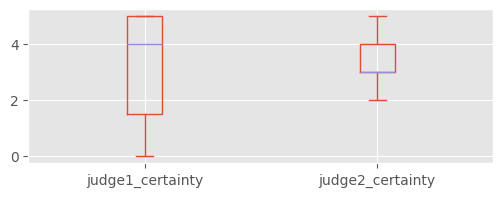

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
data[['judge1_certainty', 'judge2_certainty']].plot.box(figsize=(6,2));

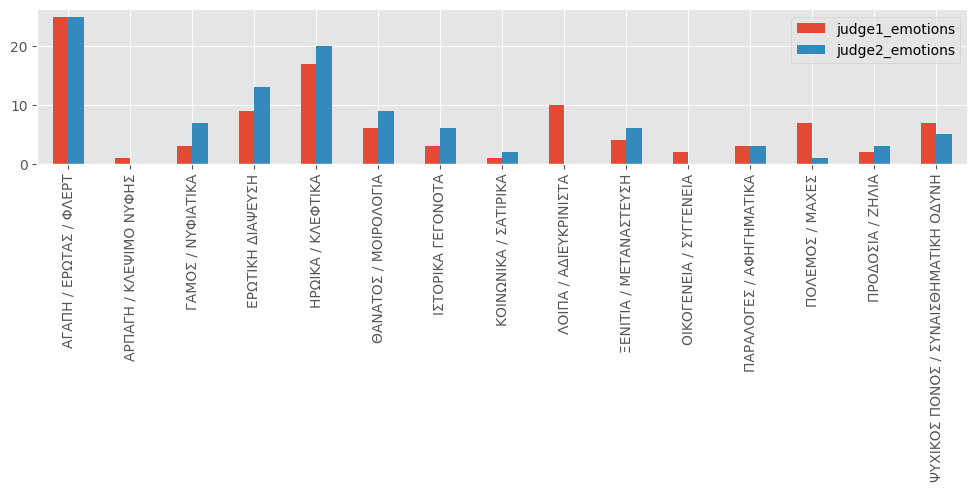

In [ ]:
import matplotlib.pyplot as plt;
plt.style.use('ggplot') # scientific style for best comparison
import seaborn as sns
counts = data[['judge1_emotions', 'judge2_emotions']].apply(pd.Series.value_counts)
counts.plot.bar(figsize=(12,2))
sns.despine()

#### Percentage ageement

In [ ]:
import numpy as np

def percent_agreement(a, b):
    return np.mean(a == b)

print(f"Percent agreement: {percent_agreement(data['judge1_emotions'], data['judge2_emotions']):.3f}")

Percent agreement: 0.600


#### Cohen's kappa

In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(data['judge1_emotions'], data['judge2_emotions'])
print(f"Cohen's kappa: {kappa:.3f}")

Cohen's kappa: 0.542


In [ ]:
pd.crosstab(
    data['judge1_emotions'],
    data['judge2_emotions'],
    rownames=['Judge1'],
    colnames=['Judge2']
)

Judge2,ΑΓΑΠΗ / ΕΡΩΤΑΣ / ΦΛΕΡΤ,ΓΑΜΟΣ / ΝΥΦΙΑΤΙΚΑ,ΕΡΩΤΙΚΗ ΔΙΑΨΕΥΣΗ,ΗΡΩΙΚΑ / ΚΛΕΦΤΙΚΑ,ΘΑΝΑΤΟΣ / ΜΟΙΡΟΛΟΓΙΑ,ΙΣΤΟΡΙΚΑ ΓΕΓΟΝΟΤΑ,ΚΟΙΝΩΝΙΚΑ / ΣΑΤΙΡΙΚΑ,ΞΕΝΙΤΙΑ / ΜΕΤΑΝΑΣΤΕΥΣΗ,ΠΑΡΑΛΟΓΕΣ / ΑΦΗΓΗΜΑΤΙΚΑ,ΠΟΛΕΜΟΣ / ΜΑΧΕΣ,ΠΡΟΔΟΣΙΑ / ΖΗΛΙΑ,ΨΥΧΙΚΟΣ ΠΟΝΟΣ / ΣΥΝΑΙΣΘΗΜΑΤΙΚΗ ΟΔΥΝΗ
Judge1,,,,,,,,,,,,
ΑΓΑΠΗ / ΕΡΩΤΑΣ / ΦΛΕΡΤ,19,1,4,0,0,0,0,1,0,0,0,0
ΑΡΠΑΓΗ / ΚΛΕΨΙΜΟ ΝΥΦΗΣ,1,0,0,0,0,0,0,0,0,0,0,0
ΓΑΜΟΣ / ΝΥΦΙΑΤΙΚΑ,0,3,0,0,0,0,0,0,0,0,0,0
ΕΡΩΤΙΚΗ ΔΙΑΨΕΥΣΗ,1,0,7,0,0,0,0,0,0,0,0,1
ΗΡΩΙΚΑ / ΚΛΕΦΤΙΚΑ,0,0,0,14,1,2,0,0,0,0,0,0
ΘΑΝΑΤΟΣ / ΜΟΙΡΟΛΟΓΙΑ,0,0,0,1,5,0,0,0,0,0,0,0
ΙΣΤΟΡΙΚΑ ΓΕΓΟΝΟΤΑ,0,0,0,0,0,2,0,0,0,1,0,0
ΚΟΙΝΩΝΙΚΑ / ΣΑΤΙΡΙΚΑ,0,0,0,0,0,0,1,0,0,0,0,0
ΛΟΙΠΑ / ΑΔΙΕΥΚΡΙΝΙΣΤΑ,1,1,0,2,0,1,1,1,1,0,2,0


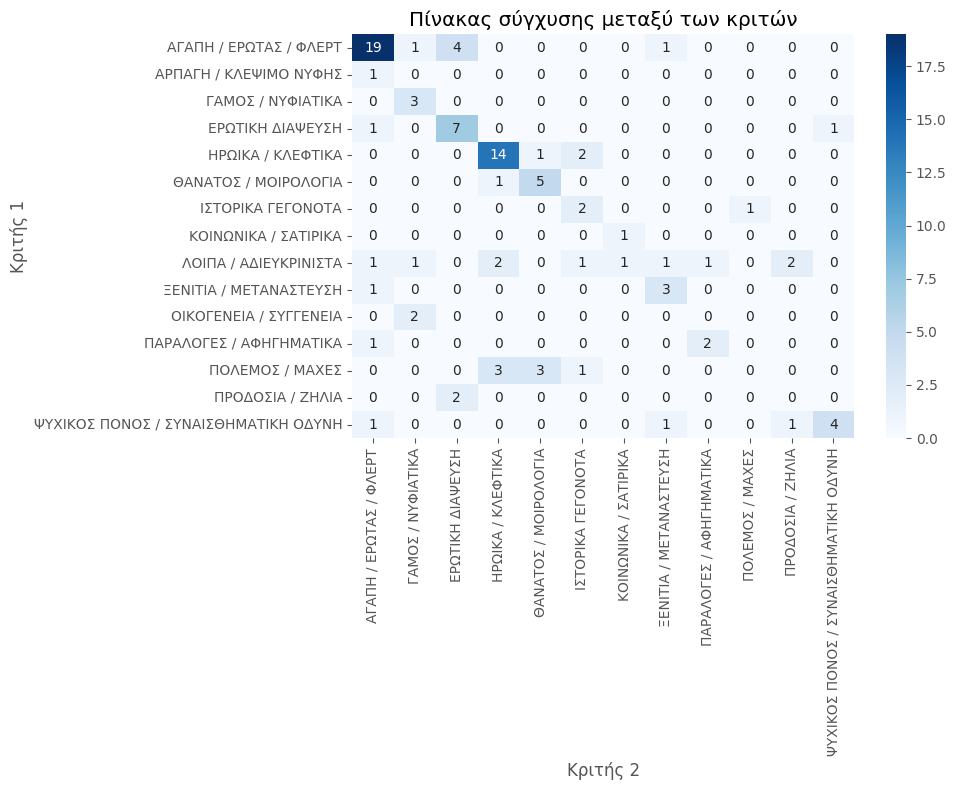

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(
    data['judge1_emotions'],
    data['judge2_emotions']
)

plt.figure(figsize=(10,8))
sns.heatmap(
    ct,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Πίνακας σύγχυσης μεταξύ των κριτών")
plt.ylabel("Κριτής 1")
plt.xlabel("Κριτής 2")
plt.tight_layout()
plt.show()

In [ ]:
high_conf = data[
    (data['judge1_certainty'] >= 4) &
    (data['judge2_certainty'] >= 4)
]

kappa_high = cohen_kappa_score(
    high_conf['judge1_emotions'],
    high_conf['judge2_emotions']
)

print(f"Kappa (high certainty only): {kappa_high:.3f}")

Kappa (high certainty only): 0.863


In [ ]:
high_conf.shape

(62, 6)

### Looking inside the low-confidence zone


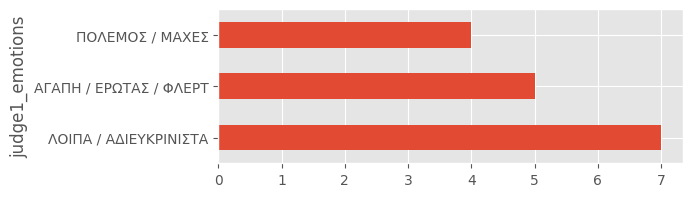

In [ ]:
data[data.judge1_certainty<3].judge1_emotions.value_counts()[:3].plot.barh(figsize=(6,2));